<a href="https://colab.research.google.com/github/Aysuliu/computer_vision/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch

In [2]:
import torch

In [3]:
print(torch.__version__)

2.11.0+cu128


In [4]:
print("cuda available:", torch.cuda.is_available() )

cuda available: True


In [5]:
scalar = torch.tensor(5)
print(scalar)
print(scalar.shape)
print(scalar.ndim)
print(scalar.size())

tensor(5)
torch.Size([])
0
torch.Size([])


In [6]:
vector = torch.tensor([1,2,3]) # 1D
print(vector)
print(vector.shape)
print(vector.ndim)
print(vector.size())

tensor([1, 2, 3])
torch.Size([3])
1
torch.Size([3])


In [8]:
matrix = torch.tensor([[1,2,3],
                      [4,5,6]]) # 2D
print(matrix)
print(matrix.shape)
print(matrix.ndim)
print(matrix.size())

tensor([[1, 2, 3],
        [4, 5, 6]])
torch.Size([2, 3])
2
torch.Size([2, 3])


In [9]:
tensor3d = torch.stack([matrix,matrix + 10]) # 3D
print(tensor3d)
print(tensor3d.shape) # [2,2,3] 2 matrices => stack | 2 rows in each matrix | 3 columns (height, width)
print(tensor3d.ndim)
print(tensor3d.size())

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[11, 12, 13],
         [14, 15, 16]]])
torch.Size([2, 2, 3])
3
torch.Size([2, 2, 3])


In [10]:
random_numbers = torch.rand(2,3) # 0~1 numbers
print(random_numbers)
print(random_numbers.shape)
print(random_numbers.dtype)
print(random_numbers.device)


tensor([[0.6516, 0.9728, 0.9846],
        [0.0773, 0.8102, 0.4491]])
torch.Size([2, 3])
torch.float32
cpu


In [12]:
print("Zeros:", torch.zeros(3,3))

Zeros: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [13]:
print("Ones:", torch.ones(2,4))

Ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [15]:
x = torch.tensor([[1,2], [3,4]])
y = torch.tensor([[5,6], [7,8]])

print("Addition:", x+y) #element wise addition
print("====================")
print("Multiplication:", x*y) # element wise multiplication
print("====================")
print('Matrix Multiplication', x@y) # matrix multiplication


Addition: tensor([[ 6,  8],
        [10, 12]])
Multiplication: tensor([[ 5, 12],
        [21, 32]])
Matrix Multiplication tensor([[19, 22],
        [43, 50]])


# [1,2] * [5,7] = 1*5 + 2*7 = 5+14 = 19
# [1,2] * [6,8] = 1*6 + 2*8 = 6+16 = 22

In [16]:
# Import Pytorch and matplot
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.11.0+cu128'

In [17]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [23]:
# Create range values
start = 0
end = 1
step = 0.02

# Define weight and bias for the linear model
weight = 0.7
bias = 0.3

# Create x & y features
X = torch.arange(start,end,step).unsqueeze(dim=1) # without unsqueeze errors can happen later
y = weight * X + bias

print("X:", X)
print("y:", y)

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])
y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
   

(40, 40, 10, 10)

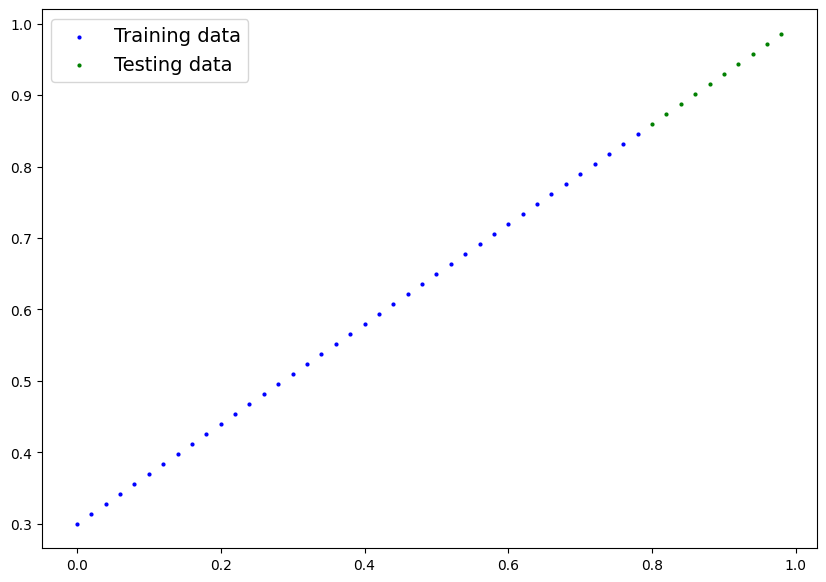

In [25]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10,7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  #Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size":14})

plot_predictions()

In [26]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1, #weight & bias
                                  out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes)
torch.manual_seed(42)

# Create an instance of the model
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [27]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

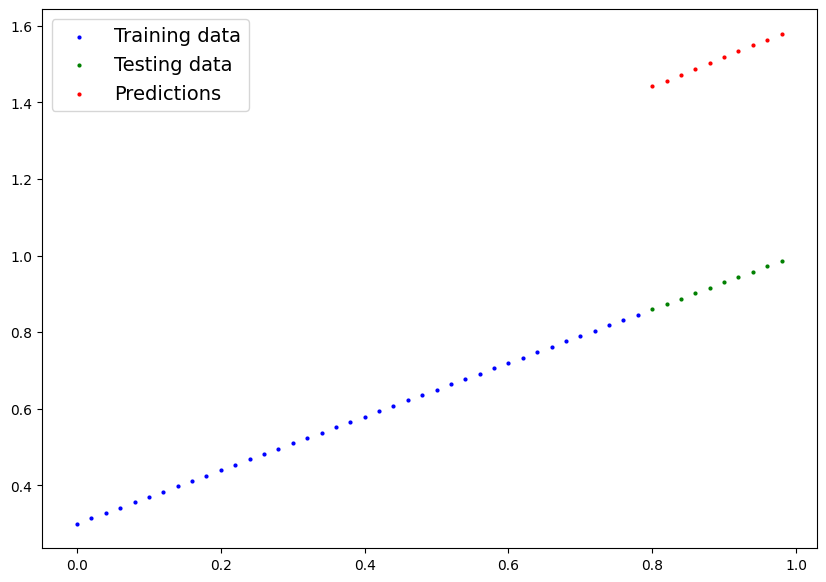

In [28]:
# See model's untained predictions (on test set)
model_1.eval()
with torch.inference_mode():
  y_preds_early = model_1(X_test)

plot_predictions(predictions=y_preds_early)

In [30]:
# Set the number of epochs
epochs = 1000

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)
model_1.to(device)

for epoch in range(epochs):
  model_1.train() # train mode is on by default
  y_pred = model_1(X_train) # step 1 forward pass
  loss = loss_fn(y_pred, y_train) # step 2 calculate loss
  optimizer.zero_grad() # step 3 zero gradient optimizer
  loss.backward() # step 4 loss backward
  optimizer.step() # step 5
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 0.5551779270172119 | Test Loss: 0.5739762187004089
Epoch: 100 | Loss: 0.006215683650225401 | Test Loss: 0.014086711220443249
Epoch: 200 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 300 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 400 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 500 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 600 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 700 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 800 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 900 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882


In [34]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

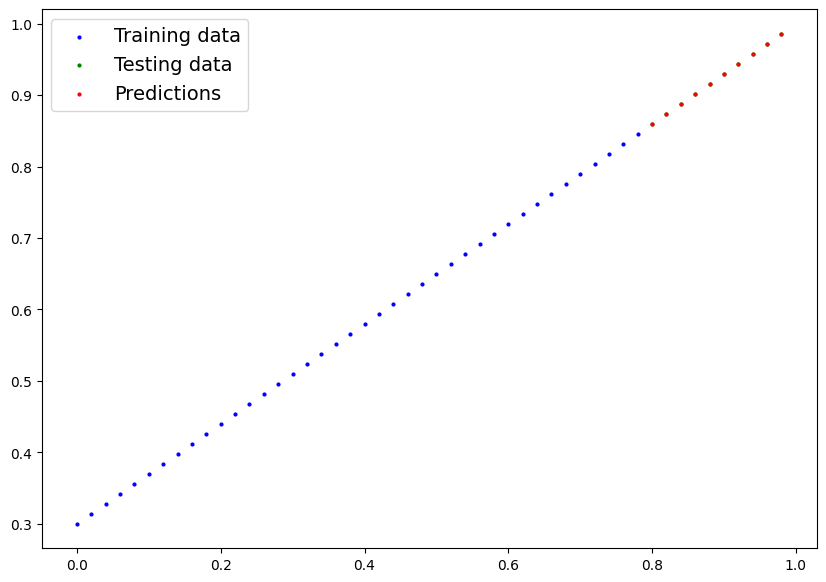

In [35]:
plot_predictions(train_data=X_train.cpu(),
                     train_labels=y_train.cpu(),
                     test_data=X_test.cpu(),
                     test_labels=y_test.cpu(),
                     predictions=y_preds.cpu())

In [36]:
torch.save(model_1.state_dict(), 'trained_model.pth')

In [37]:
loaded_model = LinearRegressionModelV2()
loaded_model.load_state_dict(torch.load('trained_model.pth'))
loaded_model

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)